In [33]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE

In [34]:
# load data (model)
res_savename_ext = "post_processed_test_labelled_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v260626_v260626_geo"

extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
# load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_gaps_v050426_v070426_geo"
labelled_df = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

In [35]:
#reformat output
labelled_df = format_output(labelled_df)
extracted_df = format_output(extracted_df)
#DEF_CRS_EPSG = "EPSG:4326"
#labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)


In [36]:
labelled_df.quanti.value_counts()

quanti
quanti    328
quali     155
Name: count, dtype: int64

In [37]:
mask = extracted_df.apply(lambda x: any([haz for haz in x.hazards if haz in ["Unknown"]]), axis=1)
pd.DataFrame(extracted_df[mask])

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_nomin_sim_below_th,flag_nomin_translate,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,flag_pop_cntry,geometry


In [38]:
pd.DataFrame(extracted_df[extracted_df["appealCode"] == "MDRSZ004"])

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_nomin_sim_below_th,flag_nomin_translate,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,flag_pop_cntry,geometry


In [39]:
extracted_df.hazards.explode().value_counts()

hazards
Earthquake                  92
Flood                       59
Mass movement               55
Extreme cold temperature    51
Convective storm            35
Other storm                 34
Drought                     17
Extreme warm temperature    15
Wildfire                     8
Epidemic                     7
Wave action                  6
Conflict                     2
Name: count, dtype: int64

In [40]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Affected People                                28
DREF Allocation & Funding requirements         17
Human Deaths                                   17
Residential Buildings                          17
Transportation                                 15
Assisted People                                15
Agriculture and Access to Food                 13
Economy and Livelihood                          9
Human Health and Wellbeing                      9
Healthcare                                      9
Targeted People                                 9
Injured People                                  8
Education                                       7
Displaced People                                5
Water, Sanitation, and Hygiene                  4
Missing People                                  3
Informal Settlements                            3
Undefined Infrastructure and Service Access     2
Infected and Ill People                         2
Homeless People                     

In [41]:
flag_cols = [label for label in extracted_df.columns if "flag_" in label or "valid_errors_" in label]

In [42]:
flag_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_haz',
 'valid_errors_dates',
 'flag_value_not_in_text',
 'flag_missing_startYear',
 'flag_missing_endYear',
 'flag_missing_startMonth',
 'flag_missing_endMonth',
 'flag_missing_startDay',
 'flag_missing_endDay',
 'flag_startYear_after_endYear',
 'flag_inconsistent_year',
 'flag_inconsistent_month',
 'flag_inconsistent_day',
 'flag_impactSubtype_reclass',
 'flag_unknown_subtype',
 'flag_hazards_reclass',
 'flag_hazards_unknown',
 'flag_remove_number_unit',
 'flag_remove_number_unit_error',
 'flag_SI_unit_standardization',
 'flag_SI_unit_standardization_error',
 'flag_unit_harmonization',
 'flag_non_currency_unit_conversion',
 'flag_non_currency_unit_conversion_error',
 'flag_non-SI_unit_standardization_error',
 'flag_non-SI_unit_standardization',
 'flag_people_unit_normalization',
 'flag_currency_conversion',
 'flag_currency_conversion_error',
 'flag_reclass_subtype_from_unit',
 'flag_impactSubtype_merged',
 'flag_inferred

In [43]:
extracted_df.columns

Index(['impactSubtype', 'impactValue', 'impactValueMin', 'impactValueMax',
       'impactValuePrecision', 'impactUnit', 'valueAnnotation',
       'valid_errors_impactValue', 'location', 'locationAnnotation',
       'valid_errors_loc', 'hazards', 'hazardsAnnotation', 'valid_errors_haz',
       'startYear', 'startMonth', 'startDay', 'endYear', 'endMonth', 'endDay',
       'dateAnnotation', 'valid_errors_dates', 'appealCode', 'reportDate',
       'reportLink', 'disasterType', 'nathaz_text', 'quanti',
       'flag_value_not_in_text', 'flag_missing_startYear',
       'flag_missing_endYear', 'flag_missing_startMonth',
       'flag_missing_endMonth', 'flag_missing_startDay', 'flag_missing_endDay',
       'flag_startYear_after_endYear', 'flag_inconsistent_year',
       'flag_inconsistent_month', 'flag_inconsistent_day',
       'flag_impactSubtype_reclass', 'flag_unknown_subtype',
       'flag_hazards_reclass', 'flag_hazards_unknown',
       'flag_remove_number_unit', 'flag_remove_number_unit_e

In [44]:

#extracted_df["impactUnit"] = extracted_df["impactUnit"].replace({"nan of null": "null"})
extracted_df["impactUnit"].value_counts()

impactUnit
people                                   74
null                                     57
EUR                                      17
homes                                    12
healthcare structures                     6
roads                                     4
education structures                      3
affected animals                          3
informal settlements                      2
days                                      2
kg of compound feed                       1
years record snow                         1
businesses                                1
motorcycles                               1
transportation structures                 1
mosque                                    1
m**3 of water                             1
km**2 of crop production and forestry     1
mattresses                                1
medicines                                 1
blankets                                  1
personal hygiene kits                     1
food rations and snac

In [45]:
extracted_df[extracted_df["impactUnit"]=="volailles et bovins"]["appealCode"]

Series([], Name: appealCode, dtype: object)

In [46]:
extracted_df.impactSubtype.nunique()

21

In [47]:
extracted_df.locationLowestAdmin.value_counts()

locationLowestAdmin
ADM_0    144
ADM_1     44
ADM_2      6
Name: count, dtype: int64

In [52]:
int(float("0.0"))

0

In [53]:
def normalize_flags(x):
    if x is None:
        return 0
    elif isinstance(x, bool):
        return int(x)
    elif isinstance(x, (int, float)):
        return int(x)
    elif isinstance(x, str):
        try:
            return int(float(x))
        except ValueError:
            raise ValueError(
                f"Invalid string value for flag column: {x}. Expected a string that can be converted to int."
            )
    else:
        raise ValueError(
            f"Invalid value for flag column: {x}. Expected None or bool, got {type(x).__name__}."
        )
extracted_df[flag_cols] = extracted_df[flag_cols].map(lambda x: normalize_flags(x))

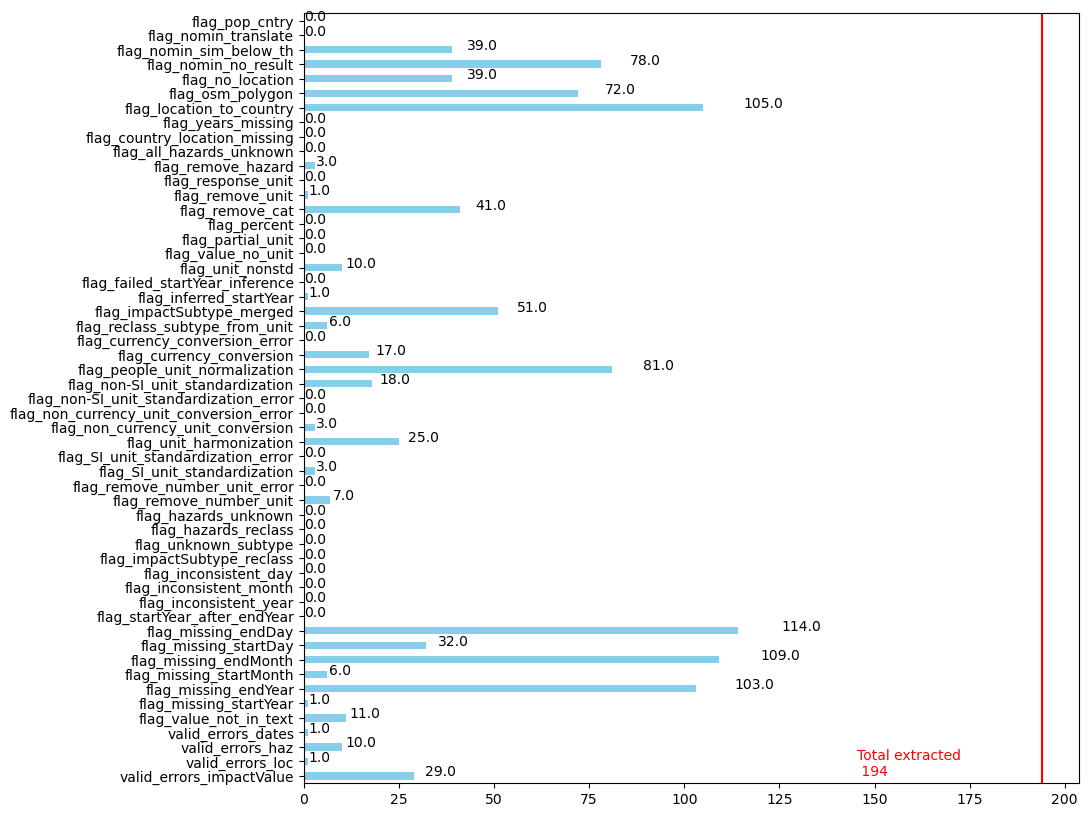

In [56]:
extracted_df["flag_value_not_in_text"] = extracted_df["flag_value_not_in_text"].fillna(0).astype(np.float64)
ax = extracted_df[flag_cols].sum().plot(kind="barh", figsize=(10, 10), color="skyblue")
ax.axvline(len(extracted_df), color="red")
ax.text(len(extracted_df)*0.75, 0, f"Total extracted\n {len(extracted_df)}", color="red")
for i, v in enumerate(extracted_df[flag_cols].sum()):
    ax.text(v*1.1, i, f"{v}", color="black")
#extracted_df[["appealCode"]+ flag_cols].plot(kind="barh")

In [ ]:
extracted_df[extracted_df.appealCode=="MDRSD034"][["location", "locationPolygon", "country_iso3", "flag_geocoding_osm", "flag_geocoding_country"]]

,location,locationPolygon,country_iso3,flag_geocoding_osm,flag_geocoding_country
9022,"[Central Darfur, East Darfur, Kassala, North D...","[Blue Nile, Central Darfur, East Darfur, Madei...","[EGY, SDN]",1.0,0.0
9023,"[Gedaref, Kassala]","[Madeinat Al Gedaref, Madeinat Kassala, Reifi ...",[SDN],1.0,0.0
9024,"[Central Darfur, East Darfur, Kassala, North D...","[Blue Nile, Central Darfur, East Darfur, Madei...","[EGY, SDN]",1.0,0.0
9025,"[Abu Hamad, Abu Sara, Atbara, Gederef, Gold lo...","[Abu Hamad, Agig, Blue Nile, Blue Nile, Easter...","[EGY, FJI, GHA, LKA, SDN, SLE, ZMB]",2.0,2.0
9026,[],[Sudan],[SDN],0.0,1.0
9027,"[Blue Nile, Gadarief, Gazira, Khartoum, North ...","[Blue Nile, Blue Nile, Eastern, Khartoum, Khar...","[EGY, FJI, GHA, LKA, SDN, SLE, ZMB]",1.0,1.0
9028,"[Central Darfur, East Darfur, Gedaref, Kassala...","[Blue Nile, Central Darfur, East Darfur, Madei...",[SDN],2.0,0.0
9029,"[Aqaba, Atbara-Abu Hamad Road, Dongola-Halfa R...","[Agig, Blue Nile, Northern, Port Sudan, Red Se...",[SDN],1.0,4.0
9030,"[Aqaba, Egypt, Jebeit, Port Sudan, Sudan, Tokar]","[Agig, Blue Nile, Egypt, Port Sudan, River Nil...","[EGY, SDN]",1.0,3.0
9031,[Arba’at Dam],[Sudan],[SDN],0.0,1.0


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_99603/3303138969.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors


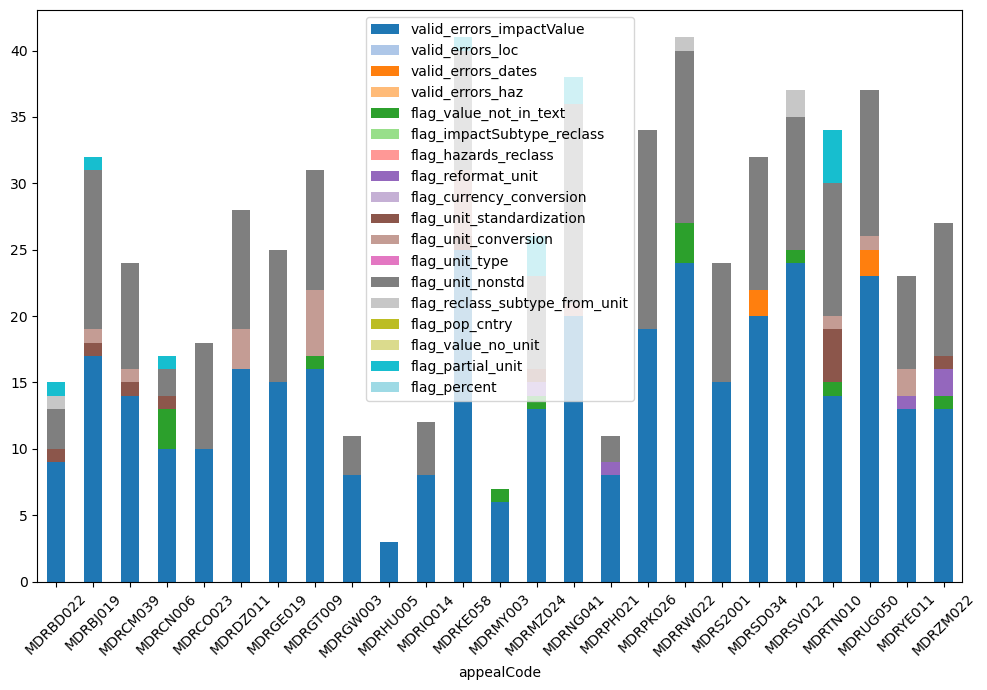

In [ ]:
from fileinput import filename
import matplotlib.cm as cm
# Number of unique flag columns
num_flags = len(flag_cols)

# Generate N unique colors from a colormap (e.g., 'tab20', 'viridis', 'nipy_spectral', etc.)
cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors
colors = [cmap(i) for i in range(num_flags)]

# Make the plot
fig, ax = plt.subplots(1,1, figsize=(10, 7))
extracted_df.groupby("appealCode")[flag_cols].sum().plot(
    kind="bar",
    ax=ax,
    rot=45,
    stacked=True,
    color=colors  # assign unique colors
)

plt.tight_layout()
fig.savefig(DATA_FIGURE / f"flags_{res_savename_ext}.png", bbox_inches="tight", dpi=300)

In [ ]:
extracted_df.groupby("appealCode")[flag_cols].sum()

,flag_value_not_in_text,flag_impactSubtype_reclass,flag_hazards_reclass,flag_reformat_unit,flag_currency_conversion,flag_unit_standardization,flag_unit_conversion,flag_unit_type,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent
appealCode,,,,,,,,,,,,,,
MDRBD022,0,0,0,0,0,1,1,0,7,1,0,0,0,0
MDRBJ019,0,0,0,0,0,2,0,0,10,0,0,0,2,0
MDRCM039,0,0,0,0,0,1,0,0,8,0,0,0,0,0
MDRCN006,0,0,0,0,0,1,0,0,1,0,0,0,1,0
MDRCO023,0,0,0,0,0,0,0,0,10,0,0,0,0,0
MDRDZ011,0,0,0,0,0,0,3,0,11,0,0,0,0,0
MDRGE019,0,0,0,0,0,0,0,0,13,0,0,0,0,0
MDRGT009,0,0,0,0,0,0,5,0,3,0,0,0,1,0
MDRGW003,0,0,0,0,0,0,1,0,1,0,0,0,0,0


In [ ]:
extracted_df[extracted_df["appealCode"] == "MDRSD034"][["hazards", "flag_hazards_reclass"]]

,hazards,flag_hazards_reclass
24,"[Flood, Epidemic, Conflict]",False
25,"[Flood, Epidemic]",False
26,[Flood],False
27,"[Flood, Epidemic, Conflict]",False
28,"[Flood, Epidemic, Conflict]",False
29,"[Flood, Epidemic]",False
30,"[Flood, Conflict, Epidemic]",False
31,[Flood],False
32,"[Conflict, Flood, Epidemic]",False
33,[Flood],False
